# ML project - Getting SNR and Mismatch from the predicted dephasing

In [20]:
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import numpy as np
from scipy.interpolate import interp1d

In [3]:


torch.manual_seed(0)
np.random.seed(0)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("device:", DEVICE)

# -------------------- Load Raw Data ---------------------------
DATA_DIR = "ML4Ph_data/data"
files = sorted(glob.glob(os.path.join(DATA_DIR, "dephasing_sample_*.csv")),
               key=lambda p: int(re.search(r"_(\d+)\.csv$", p).group(1)))
print("n files:", len(files))

def parse_file(path):
    with open(path) as fh:
        lines = fh.readlines()
    params = {}
    for item in lines[0].strip().split(","):
        k, v = item.split("=")
        params[k.strip()] = float(v)
    data = np.loadtxt(lines[2:], delimiter=",")
    return params, data[:, 0], data[:, 1]  # f [Hz], dPh [rad]

# Stack into arrays. m1, m2, rhosp, gsp + per-system (f, dPh) lists.
m1  = np.empty(len(files))
m2  = np.empty(len(files))
rho = np.empty(len(files))
gsp = np.empty(len(files))
fs, dphis = [], []
for i, fp in enumerate(files):
    p, f, d = parse_file(fp)
    m1[i], m2[i], rho[i], gsp[i] = p["m1"], p["m2"], p["rhosp"], p["gsp"]
    fs.append(f); dphis.append(d)

print("m1   :", m1.min(), m1.max())
print("m2   :", m2.min(), m2.max())
print("rho6 :", rho.min(), rho.max())
print("gsp  :", gsp.min(), gsp.max())
print("points/curve (first 5):", [len(d) for d in dphis[:5]])
     


device: cpu
n files: 10000
m1   : 1001.003 999688.526
m2   : 3.001 99.995
rho6 : 10.009 9993.165
gsp  : 2.0 2.5
points/curve (first 5): [200, 200, 200, 200, 200]


# Frequency Normalization

In [4]:
# Constants (SI)
G    = 6.67430e-11
C    = 2.99792458e8
MSUN = 1.98892e30
YR   = 365.25 * 86400.0

# Lookback window for the x=1 anchor: changed from 10 yr -> 4 yr per supervisor.
TAU_YR = 4.0

def f_isco(m1_msun, m2_msun):
    M = (m1_msun + m2_msun) * MSUN
    return C**3 / (6**1.5 * np.pi * G * M)

def f_tau(m1_msun, m2_msun, tau_sec=TAU_YR * YR):
    Mc = (m1_msun * m2_msun)**(3/5) / (m1_msun + m2_msun)**(1/5) * MSUN
    # f = (1/pi) * (5 / (256 tau))**(3/8) * (G Mc / c^3)**(-5/8)
    return (1.0 / np.pi) * (5.0 / (256.0 * tau_sec))**(3/8) * (G * Mc / C**3)**(-5/8)

fc    = f_isco(m1, m2)
f_tau_arr = f_tau(m1, m2)
print(f"fc      range: {fc.min():.4e}  {fc.max():.4e}")
print(f"f_{TAU_YR:g}yr  range: {f_tau_arr.min():.4e}  {f_tau_arr.max():.4e}")

# Sanity: how does each system's actual f-range overlap [f_tau, fc]?
fmin_data = np.array([f[0]  for f in fs])
fmax_data = np.array([f[-1] for f in fs])
print(f"\nfmin_data / f_tau (median): {np.median(fmin_data / f_tau_arr):.4f}")
print(f"fmax_data / fc    (median): {np.median(fmax_data / fc):.4f}")

fc      range: 4.3973e-03  4.3774e+00
f_4yr  range: 7.8091e-04  1.6024e-02

fmin_data / f_tau (median): 0.9199
fmax_data / fc    (median): 1.0010


In [5]:
# Build x for each system, drop the trailing dPh=0 point at merger, take ln(dPh).
# Every file has exactly one zero (the last entry, by definition of dephasing at merger),
# so this is safe and keeps a uniform pre-resample length of 199 across all systems.
assert all((d[-1] == 0) and (d[:-1] > 0).all() for d in dphis), "unexpected zero pattern"

xs, log_dphis = [], []
for i in range(len(files)):
    x = (fs[i][:-1] - fc[i]) / (f_tau_arr[i] - fc[i])
    xs.append(x)
    log_dphis.append(np.log(dphis[i][:-1]))

assert all(len(x) == 199 for x in xs)  # shape consistency check before resampling

# Look at x ranges
xmins = np.array([x.min() for x in xs])
xmaxs = np.array([x.max() for x in xs])
print("x.min  -- min:", xmins.min(), "median:", np.median(xmins), "max:", xmins.max())
print("x.max  -- min:", xmaxs.min(), "median:", np.median(xmaxs), "max:", xmaxs.max())
     

x.min  -- min: -0.1070374883609459 median: 0.015612776196193605 max: 0.023710501013420125
x.max  -- min: 1.0000911344308259 median: 1.0021990088366244 max: 1.1511184086282258


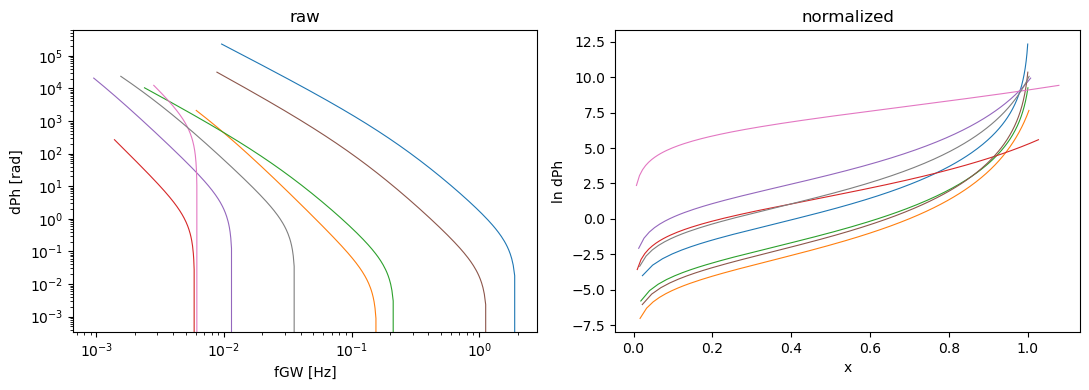

In [6]:
# Quick visualization of a few raw curves in (x, log dPh).
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for i in np.random.choice(len(files), 8, replace=False):
    ax[0].plot(fs[i], dphis[i], lw=0.8)
    ax[1].plot(xs[i], log_dphis[i], lw=0.8)
ax[0].set(xscale="log", yscale="log", xlabel="fGW [Hz]", ylabel="dPh [rad]", title="raw")
ax[1].set(xlabel="x", ylabel="ln dPh", title="normalized")
plt.tight_layout(); plt.show()
     

# REsample onto common x-grid

common x-grid: [0.0237, 1.0001], 200 points
Y shape: (10000, 200)


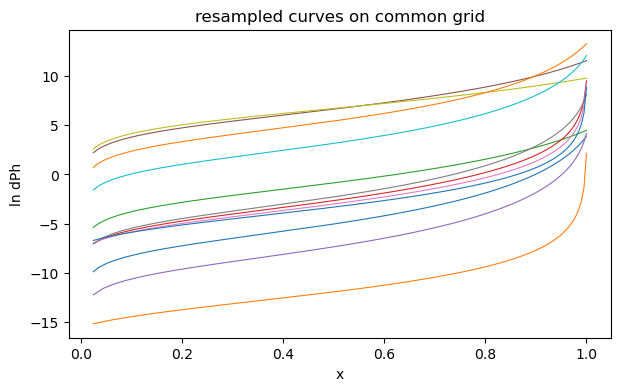

In [7]:

X_LO = float(np.max(xmins))
X_HI = float(np.min(xmaxs))
N_X  = 200
x_grid = np.linspace(X_LO, X_HI, N_X)
print(f"common x-grid: [{X_LO:.4f}, {X_HI:.4f}], {N_X} points")

# Note: x decreases as the inspiral progresses (x=1 at f_tau, x=0 at merger),
# so xs[i] is monotonically *decreasing*. np.interp requires increasing xp,
# so flip both arrays before interpolating.
Y = np.empty((len(files), N_X))
for i in range(len(files)):
    xi = xs[i][::-1]
    yi = log_dphis[i][::-1]
    assert np.all(np.diff(xi) > 0), f"x not strictly increasing after flip (system {i})"
    Y[i] = np.interp(x_grid, xi, yi)
print("Y shape:", Y.shape)

# sanity plot
fig, ax = plt.subplots(figsize=(7,4))
for i in np.random.choice(len(files), 12, replace=False):
    ax.plot(x_grid, Y[i], lw=0.8)
ax.set(xlabel="x", ylabel="ln dPh", title="resampled curves on common grid")
plt.show()
     

# Inputs: log-transform and standardize

In [8]:

theta_raw = np.column_stack([np.log(m1), np.log(m2), np.log(rho), gsp])
print("theta_raw shape:", theta_raw.shape)

idx = np.arange(len(files))
idx_trainval, idx_test = train_test_split(idx, test_size=0.10, random_state=0)
idx_train, idx_val     = train_test_split(idx_trainval, test_size=1/9, random_state=0)  # 0.10 of total
print(f"train/val/test = {len(idx_train)}/{len(idx_val)}/{len(idx_test)}")

theta_mu  = theta_raw[idx_train].mean(0)
theta_std = theta_raw[idx_train].std(0)
theta = (theta_raw - theta_mu) / theta_std

theta_raw shape: (10000, 4)
train/val/test = 8000/1000/1000


# PCA Basis (train-only) -> project all curves 

In [9]:
K = 4
pca = PCA(n_components=K)
pca.fit(Y[idx_train])
print("explained variance ratio (cum):", np.cumsum(pca.explained_variance_ratio_))

coeffs = pca.transform(Y)  # (N, K)

# Standardize coefficients using training stats (helps MLP optimization).
c_mu  = coeffs[idx_train].mean(0)
c_std = coeffs[idx_train].std(0)
coeffs_n = (coeffs - c_mu) / c_std
print("coeffs shape:", coeffs.shape)

explained variance ratio (cum): [0.98892625 0.99920644 0.99996132 0.9999842 ]
coeffs shape: (10000, 4)


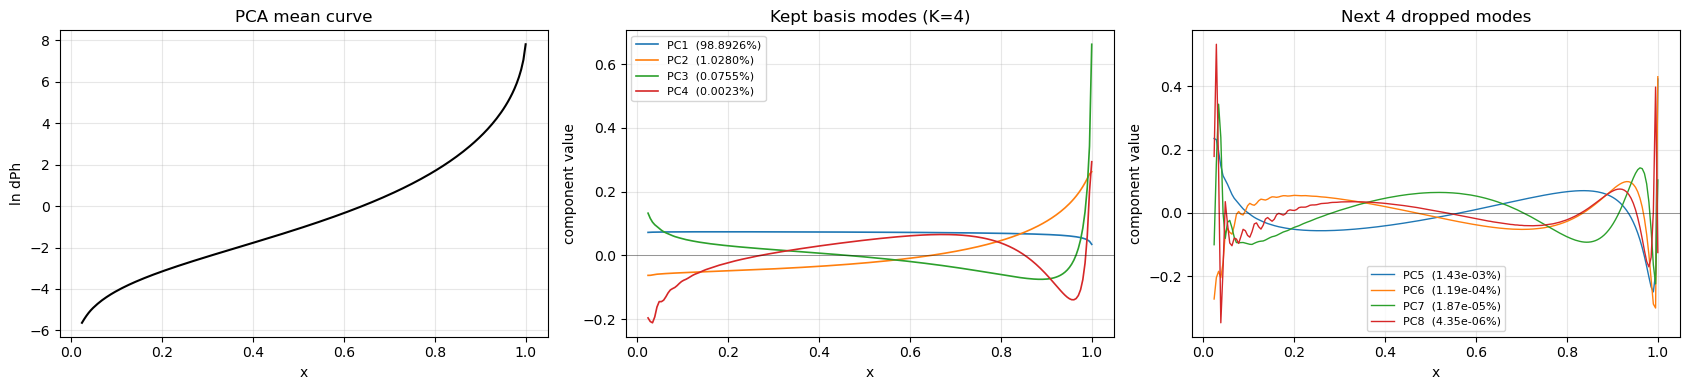

In [10]:
# Visualize the PCA basis: mean curve + the K kept modes + the next N_DROPPED modes.
# The dropped panel uses a separate, wider PCA fit purely for visualization — does not affect the model.
pca_diag = PCA(n_components=2*K).fit(Y[idx_train])

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].plot(x_grid, pca.mean_, "k-", lw=1.5)
axes[0].set(xlabel="x", ylabel="ln dPh", title="PCA mean curve")
axes[0].grid(alpha=0.3)

for k in range(K):
    evr = pca.explained_variance_ratio_[k]
    axes[1].plot(x_grid, pca.components_[k], lw=1.2,
                 label=f"PC{k+1}  ({evr*100:.4f}%)")
axes[1].axhline(0, color="k", lw=0.5, alpha=0.5)
axes[1].set(xlabel="x", ylabel="component value",
            title=f"Kept basis modes (K={K})")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

for k in range(K, 2*K):
    evr = pca_diag.explained_variance_ratio_[k]
    axes[2].plot(x_grid, pca_diag.components_[k], lw=1.0,
                 label=f"PC{k+1}  ({evr*100:.2e}%)")
axes[2].axhline(0, color="k", lw=0.5, alpha=0.5)
axes[2].set(xlabel="x", ylabel="component value",
            title=f"Next {K} dropped modes")
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# MLP: 4 params -> K coeffictients

In [11]:
class MLP(nn.Module):
    def __init__(self, d_in=4, d_out=K, width=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, width), nn.ReLU(),
            nn.Linear(width, width), nn.ReLU(),
            nn.Linear(width, width), nn.ReLU(),
            nn.Linear(width, d_out),
        )
    def forward(self, x): return self.net(x)

def to_t(a): return torch.as_tensor(a, dtype=torch.float32, device=DEVICE)

X_tr, y_tr = to_t(theta[idx_train]), to_t(coeffs_n[idx_train])
X_va, y_va = to_t(theta[idx_val]),   to_t(coeffs_n[idx_val])
X_te, y_te = to_t(theta[idx_test]),  to_t(coeffs_n[idx_test])

model = MLP().to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

EPOCHS = 2500
BATCH  = 1000

best_va = float("inf"); best_state = None
hist = {"train": [], "val": []}
n_tr = X_tr.shape[0]

for epoch in range(EPOCHS):
    model.train()
    perm = torch.randperm(n_tr, device=DEVICE)
    losses = []
    for s in range(0, n_tr, BATCH):
        b = perm[s:s+BATCH]
        opt.zero_grad()
        pred = model(X_tr[b])
        loss = loss_fn(pred, y_tr[b])
        loss.backward(); opt.step()
        losses.append(loss.item())
    model.eval()
    with torch.no_grad():
        va = loss_fn(model(X_va), y_va).item()
    hist["train"].append(float(np.mean(losses))); hist["val"].append(va)
    if va < best_va - 1e-6:
        best_va = va; best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
    if epoch % 100 == 0:
        print(f"epoch {epoch:4d}  train {hist['train'][-1]:.4e}  val {va:.4e}")

model.load_state_dict(best_state)
print("loaded best model, val MSE =", best_va)

epoch    0  train 9.8240e-01  val 1.0069e+00
epoch  100  train 2.6814e-03  val 2.6393e-03
epoch  200  train 5.9111e-04  val 6.2017e-04
epoch  300  train 3.0067e-04  val 3.7159e-04
epoch  400  train 2.0118e-04  val 2.8005e-04
epoch  500  train 1.4600e-04  val 2.2397e-04
epoch  600  train 1.1556e-04  val 1.9528e-04
epoch  700  train 9.5724e-05  val 1.6881e-04
epoch  800  train 9.6091e-05  val 1.6354e-04
epoch  900  train 9.9030e-05  val 1.5012e-04
epoch 1000  train 6.0399e-05  val 1.2872e-04
epoch 1100  train 7.2811e-05  val 1.4860e-04
epoch 1200  train 6.5700e-05  val 1.1839e-04
epoch 1300  train 4.6359e-05  val 1.1689e-04
epoch 1400  train 6.1942e-05  val 1.3316e-04
epoch 1500  train 4.0722e-05  val 1.0319e-04
epoch 1600  train 4.7172e-05  val 1.2654e-04
epoch 1700  train 3.7291e-05  val 1.1046e-04
epoch 1800  train 3.2374e-05  val 9.1503e-05
epoch 1900  train 3.5213e-05  val 9.8579e-05
epoch 2000  train 3.8382e-05  val 8.7766e-05
epoch 2100  train 4.0382e-05  val 1.0205e-04
epoch 2200

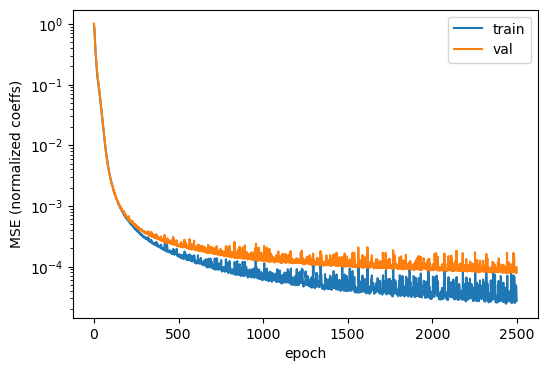

In [12]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(hist["train"], label="train")
ax.plot(hist["val"], label="val")
ax.set(yscale="log", xlabel="epoch", ylabel="MSE (normalized coeffs)")
ax.legend(); plt.show()

# Evaluation - RMSE 

In [ ]:
@torch.no_grad()
def predict_curves(theta_arr_norm):
    model.eval()
    c_n = model(to_t(theta_arr_norm)).cpu().numpy()
    c   = c_n * c_std + c_mu
    Y_hat = pca.inverse_transform(c)
    return c, Y_hat

# coefficient-space error (in unnormalized coeff units)
c_te_pred, Y_te_pred = predict_curves(theta[idx_test])
c_te_true            = coeffs[idx_test]
Y_te_true            = Y[idx_test]

coef_mse = ((c_te_pred - c_te_true)**2).mean()
print(f"test coefficient MSE          : {coef_mse:.4e}")

# curve-space error in ln dPh
err = Y_te_pred - Y_te_true
rmse_per_curve = np.sqrt((err**2).mean(axis=1))  # ln-units
print(f"test curve RMSE in ln(dPh)    : median {np.median(rmse_per_curve):.3e}, "
      f"mean {rmse_per_curve.mean():.3e}, p95 {np.quantile(rmse_per_curve, 0.95):.3e}")

# Also report a "fractional" sense: exp(rmse) − 1 ≈ multiplicative error on dPh.
print(f"≈ multiplicative error on dPh : median {np.exp(np.median(rmse_per_curve))-1:.2%}")

basis_floor = np.sqrt(((Y[idx_test] - pca.inverse_transform(pca.transform(Y[idx_test])))**2).mean(axis=1)).mean()
print(f"basis floor (PCA reconstruction error) : {basis_floor:.3e}")
print(f"model error: {np.mean(rmse_per_curve) - basis_floor:.3e} (model error above basis floor)")










pojp';k grgar  
jgdfgh

test coefficient MSE          : 2.0124e-02
test curve RMSE in ln(dPh)    : median 2.061e-02, mean 2.331e-02, p95 4.619e-02
≈ multiplicative error on dPh : median 2.08%
basis floor (PCA reconstruction error) : 1.401e-02
model error: 9.296e-03 (model error above basis floor)


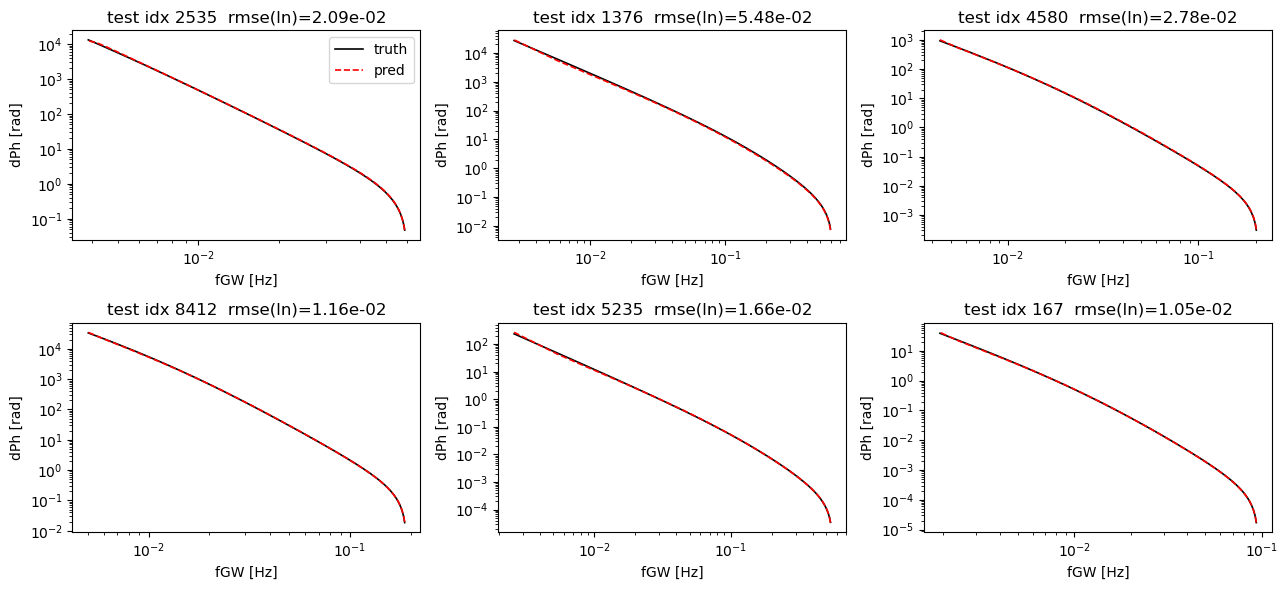

In [15]:
# Visualize a few test predictions vs truth, in physical (f, dPh) space.
# Per-system inverse mapping: f = x * (f_tau - f_c) + f_c, then dPh = exp(ln dPh).
# Each test system has its own f-grid because (f_c, f_tau) depend on (m1, m2).
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
sel = np.random.choice(len(idx_test), 6, replace=False)
for ax, j in zip(axes.flat, sel):
    sys_i = idx_test[j]
    f_axis = x_grid * (f_tau_arr[sys_i] - fc[sys_i]) + fc[sys_i]
    dphi_true = np.exp(Y_te_true[j])
    dphi_pred = np.exp(Y_te_pred[j])
    ax.plot(f_axis, dphi_true, "k-",  lw=1.2, label="truth")
    ax.plot(f_axis, dphi_pred, "r--", lw=1.2, label="pred")
    ax.set(xscale="log", yscale="log",
           xlabel="fGW [Hz]", ylabel="dPh [rad]",
           title=f"test idx {sys_i}  rmse(ln)={rmse_per_curve[j]:.2e}")
axes[0,0].legend()
plt.tight_layout(); plt.show()

### Slice errors by parameter region

In [16]:
# Bin the test set by each input parameter and report median curve RMSE per bin.
def slice_report(values, name, n_bins=5):
    edges = np.quantile(values, np.linspace(0, 1, n_bins+1))
    print(f"\n--- {name} ---")
    for i in range(n_bins):
        lo, hi = edges[i], edges[i+1]
        m = (values >= lo) & (values <= hi if i == n_bins-1 else values < hi)
        if m.sum() == 0: continue
        print(f"  [{lo:.3g}, {hi:.3g}]  n={m.sum():4d}  median rmse(ln) = {np.median(rmse_per_curve[m]):.3e}")

slice_report(m1[idx_test],  "m1")
slice_report(m2[idx_test],  "m2")
slice_report(rho[idx_test], "rho6")
slice_report(gsp[idx_test], "gamma_s")


--- m1 ---
  [1e+03, 4.51e+03]  n= 200  median rmse(ln) = 2.203e-02
  [4.51e+03, 1.9e+04]  n= 200  median rmse(ln) = 2.144e-02
  [1.9e+04, 6.09e+04]  n= 200  median rmse(ln) = 1.730e-02
  [6.09e+04, 2.47e+05]  n= 200  median rmse(ln) = 2.044e-02
  [2.47e+05, 9.91e+05]  n= 200  median rmse(ln) = 2.161e-02

--- m2 ---
  [3.01, 5.99]  n= 200  median rmse(ln) = 2.215e-02
  [5.99, 11.8]  n= 200  median rmse(ln) = 1.960e-02
  [11.8, 24.2]  n= 200  median rmse(ln) = 1.938e-02
  [24.2, 48.2]  n= 200  median rmse(ln) = 2.013e-02
  [48.2, 99.8]  n= 200  median rmse(ln) = 2.204e-02

--- rho6 ---
  [10.1, 38.4]  n= 200  median rmse(ln) = 2.022e-02
  [38.4, 160]  n= 200  median rmse(ln) = 1.996e-02
  [160, 602]  n= 200  median rmse(ln) = 2.003e-02
  [602, 2.59e+03]  n= 200  median rmse(ln) = 2.068e-02
  [2.59e+03, 9.99e+03]  n= 200  median rmse(ln) = 2.198e-02

--- gamma_s ---
  [2, 2.11]  n= 199  median rmse(ln) = 2.173e-02
  [2.11, 2.22]  n= 200  median rmse(ln) = 2.085e-02
  [2.22, 2.31]  n= 20

# Computing Mismatch

In [38]:
# Physical constants
# -------------------------------

G = 6.67430e-11
c = 299792458.0
M_sun = 1.98847e30

# LISA constants
# -------------------------------
L = 2.5e9
f_star = c / (2 * np.pi * L)

# LISA PSD
# -------------------------------

def P_OMS(f):
    return (1.5e-11)**2 * (1 + (2e-3 / f)**4)

def P_acc(f):
    return ((3e-15)**2 * (1 + (0.4e-3 / f)**2) * (1 + (f / 8e-3)**4))

def S_n(f):
    """ 
    Computes the power spectral density according to the LISA Consortium https://arxiv.org/pdf/1803.01944
    """
    return ((10 / (3 * L**2)) * (P_OMS(f) + 2 * (1 + np.cos(f / f_star)**2) * P_acc(f) / (2 * np.pi * f)**4) * (1 + (6/10) * (f / f_star)**2))

# Vacuum phase
# -------------------------------

def phi_vacuum(f, chirp_mass):
    """
    Computes the waveform phase for vacuum, following https://arxiv.org/pdf/2211.01362
    """
    a_V = (c**3) / (np.pi * G * chirp_mass * f)
    return (1/16) * a_V**(5/3)

# Compute phi_ddot from analytic expression
# -------------------------------

# def phi_ddot(f, phi):
#     """
#     Computes second derivative of the phase according to https://arxiv.org/pdf/2211.01362
#     """
#     dphi_df = np.gradient(phi, f)

#     return 4 * np.pi**2 * f / dphi_df

def phi_ddot_vacuum(f, chirp_mass):
    """ 
    Copmutes the phase acceleration according to https://arxiv.org/pdf/2108.04154
    """
    a_V = (np.pi * G * chirp_mass / c**3)**(-5/3)

    return (12 * np.pi**2 * f**(11/3)) / (5 * a_V)

# Build waveform
# -------------------------------

def h0(f, chirp_mass, phi_dd):
    """
    Computes the Stationary Phase Aapproximation amplitude for building the waveform as depicted in  https://arxiv.org/pdf/2211.01362
    """
    prefactor = (0.5 * (4 * np.pi**(2/3) * G**(5/3) * chirp_mass**(5/3) * f**(2/3)) / c**4)
    return prefactor * np.sqrt(2 * np.pi / phi_dd)

def build_waveform(f, delta_phi, m1, m2):
    """
    Computes the waveform phase in environment from the dephaseing and vacuum phase as shown in  https://arxiv.org/pdf/2211.01362
    1. and builds the waveform according to h^~(f)= h_0 * e^{i * Phi_tot(f)} 
    (is the h_0 given in the paper, the same amplitude that can be used like this?? we have a phase containing both vacuum and envirnonement but the amplitude is based only on vacuum??)
    """
    # masses in kg ?
    m1 *= M_sun
    m2 *= M_sun
    chirp_mass = ((m1*m2)**(3/5)) / ((m1+m2)**(1/5))

    # environmental phase
    phi_v = phi_vacuum(f, chirp_mass)
    phi_env = phi_v - delta_phi
    # phi_dd = phi_ddot(f, phi_total) # second derivative
    # phi_dd = np.maximum(phi_dd, 1e-30) # avoid division by zero if noisy differentiation (from noisy phases/near boundary)
    
    #phase acceleration for vacuum amplitude, h0 
    phi_dd = phi_ddot_vacuum(f, chirp_mass)

    # waveform
    h = h0(f, chirp_mass, phi_dd) * np.exp(1j * phi_env)
    return h

# Inner product
# -------------------------------

def inner_product(a, b, f):
    integrand = np.conj(a) * b / S_n(f)
    #integrate using the composite rapezoidal rule 

    return 4* np.real(np.trapz(integrand, f))

def overlap_maximized(h1, h2, f):
    """ 
    Measures similarity between two waveforms
    """
    # \Delta f for discrete integral calculation
    df = f[1] - f[0]

    integrand = np.conj(h1) * h2 / S_n(f) # only f>0 and proper FFT ordering...

    # FFT to scan over all time shifts, easier as a shift in time is multiplication by a phase factor in frequency space. 
    z = 4 * np.fft.ifft(integrand) * len(f) * df  ## fft assumes uniformly spaced frequencies, so the array must satisfy np.allclose(np.diff(f), np.diff(f)[0])
    
    # maximize over phase and time
    return np.max(np.abs(z))

# Faithfulness
# -------------------------------

def faithfulness(f, delta_phi_true, delta_phi_pred, m1, m2):
    """ 
    Computes the Faithfulness from the predicted waveform and the true waveform according to https://arxiv.org/pdf/2211.01362
    """
    h_true = build_waveform(f, delta_phi_true, m1, m2)
    h_pred = build_waveform(f, delta_phi_pred, m1, m2)

    # inner products
    # hd = np.abs(inner_product(h_pred, h_true, f)) # this might not be the ocrrect way to do this, only maximizes over phase not over coalescence time...
    hd = overlap_maximized(h_pred, h_true, f)
    hh = np.real(inner_product(h_pred, h_pred, f))
    dd = np.real(inner_product(h_true, h_true, f))

    #return hd / np.sqrt(hh * dd)
    F = hd / np.sqrt(hh * dd)

    # numerical safety
    F = np.clip(F, 0.0, 1.0)

    return F

# Mismatch
# -------------------------------
def mismatch(f, delta_phi_true, delta_phi_pred, m1,m2):
    """ 
    Computes the mismatch from the Faithfulness as M = 1 - F, given in https://arxiv.org/pdf/2505.09715
    """
    F = faithfulness(f, delta_phi_true, delta_phi_pred, m1, m2)
    return 1 - F

# def crit_mismatch(d, f, n=4):
#     """ 
#     Computes the critical mismatch (threshold set by detector sensitivity), below which the two waveforms cannot be distinguished by the detector,
#     from the snr which measures detectability, as shown in https://arxiv.org/pdf/2505.09715
#     """
#     snr = np.sqrt(inner_product(d, d, f))
#     M_c = n/2 * 1/snr**2
#     return M_c


def crit_mismatch(n=4, snr=200):
    return n / (2 * snr**2)



# Making sure that the frequency grid matches
def resample_waveform_data(f, dphi, n_points=4000):
    """
    Resample onto a dense uniformly-spaced frequency grid.
    Required for FFT overlap calculation.
    """
    f_uniform = np.linspace(f.min(), f.max(), n_points)
    interp = interp1d(f, dphi, kind="cubic")
    dphi_uniform = interp(f_uniform)

    return f_uniform, dphi_uniform


## Evaluating Mismatch

Critical mismatch M_c = 5e-05

Mismatch statistics
-------------------
median : 0.6203136731247297
mean   : 0.5431257836196507
max    : 0.9129301878527473

Fraction with M > M_c:
0.972


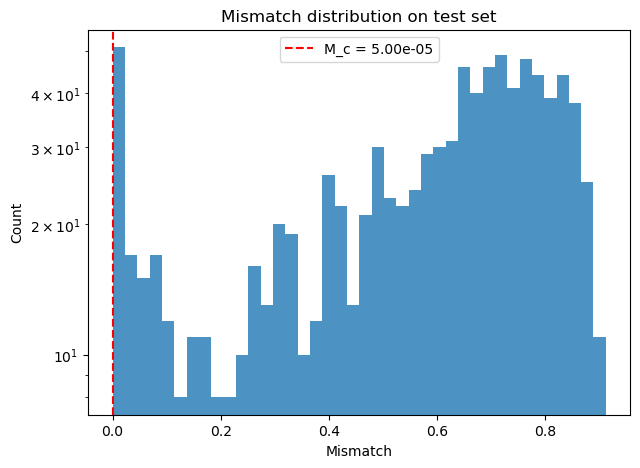

In [39]:
# ---------------- Computing Mismatch from model outputs ------------------------
# benchmark critical mismatch
SNR_BENCHMARK = 200
N_PARAMS = 4

M_c = (N_PARAMS / 2) / SNR_BENCHMARK**2

print("Critical mismatch M_c =", M_c)

mismatches = []
faithfulnesses = []

for j in range(len(idx_test)):

    sys_i = idx_test[j]

    # reconstruct physical frequency axis
    f_axis = (x_grid * (f_tau_arr[sys_i] - fc[sys_i]) + fc[sys_i])

    # predicted and true dephasings
    dphi_true = np.exp(Y_te_true[j])
    dphi_pred = np.exp(Y_te_pred[j])

    # dense uniform resampling
    f_dense, dphi_true_dense = resample_waveform_data(f_axis, dphi_true)

    _, dphi_pred_dense = resample_waveform_data(f_axis, dphi_pred)

    # system parameters
    m1_i = m1[sys_i]
    m2_i = m2[sys_i]

    # mismatch
    M = mismatch(f_dense, dphi_true_dense, dphi_pred_dense, m1_i, m2_i)

    F = 1 - M

    mismatches.append(M)
    faithfulnesses.append(F)

mismatches = np.array(mismatches)
faithfulnesses = np.array(faithfulnesses)

print()
print("Mismatch statistics")
print("-------------------")
print("median :", np.median(mismatches))
print("mean   :", np.mean(mismatches))
print("max    :", np.max(mismatches))

print()
print("Fraction with M > M_c:")
print(np.mean(mismatches > M_c))


# ------------- Plotting ------------
plt.figure(figsize=(7,5))
plt.hist(mismatches, bins=40, alpha=0.8)
plt.axvline(M_c, color="red", linestyle="--", label=f"M_c = {M_c:.2e}")
plt.xlabel("Mismatch")
plt.ylabel("Count")
plt.yscale("log")
plt.legend()
plt.title("Mismatch distribution on test set")
plt.show()

In [ ]:
# ------------------- Verify waveform construction --------------------------
M_self = mismatch(f_dense, dphi_true_dense, dphi_true_dense, m1_i, m2_i)
print(M_self)

F_same = faithfulness(f_dense, dphi_true_dense, dphi_true_dense, m1_i, m2_i)
print(F_same)

0.0
1.0


- Perfect: M=0
- acceptable GW models: $M \leq 10^{-3}$
- distinguishability threshold: $M_c = 5 * 10^{-5}$


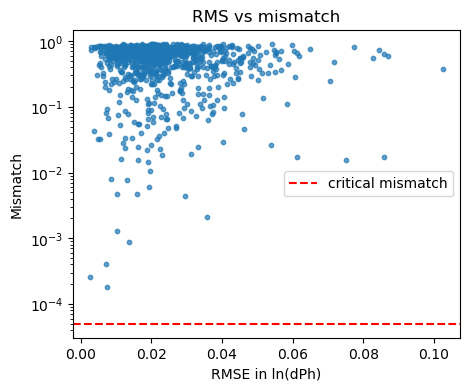

In [55]:
plt.figure(figsize=(5,4))
plt.scatter(rmse_per_curve, mismatches, s=10, alpha=0.7)
plt.axhline(M_c, color="red", linestyle="--", label="critical mismatch")
plt.xlabel("RMSE in ln(dPh)")
plt.ylabel("Mismatch")
plt.yscale("log")
plt.legend()
plt.title("RMS vs mismatch")
plt.show()

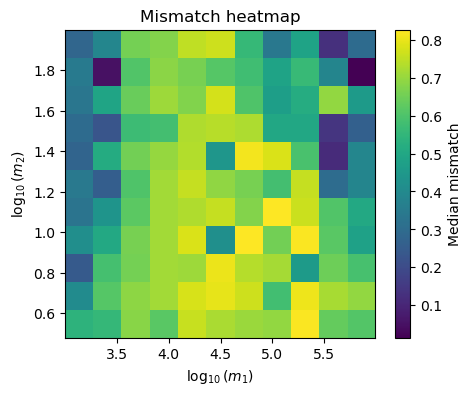

In [53]:
from scipy.stats import binned_statistic_2d

x = np.log10(m1[idx_test])
y = np.log10(m2[idx_test])
stat, xedge, yedge, binnumber = binned_statistic_2d(x, y, mismatches, statistic='median', bins=11)

plt.figure(figsize=(5,4))
plt.imshow(stat.T, origin='lower', aspect='auto', extent=[xedge[0], xedge[-1], yedge[0], yedge[-1]])
plt.xlabel(r'$\log_{10}(m_1)$')
plt.ylabel(r'$\log_{10}(m_2)$')
cbar = plt.colorbar()
cbar.set_label("Median mismatch")
plt.title("Mismatch heatmap")
plt.show()

In [44]:
bad = mismatches > M_c

print("Systems exceeding critical mismatch:")
print(np.sum(bad))

for i in np.where(bad)[0][:20]:
    sys_i = idx_test[i]
    print(
        f"sys={sys_i}  "
        f"M={mismatches[i]:.3e}  "
        f"m1={m1[sys_i]:.2e}  "
        f"m2={m2[sys_i]:.2e}  "
        f"rho={rho[sys_i]:.2e}  "
        f"gamma={gsp[sys_i]:.2f}" )
    


Systems exceeding critical mismatch:
972
sys=9394  M=5.872e-01  m1=2.26e+03  m2=5.76e+00  rho=1.97e+02  gamma=2.47
sys=898  M=5.434e-01  m1=2.79e+04  m2=3.66e+00  rho=1.61e+03  gamma=2.10
sys=2398  M=7.813e-01  m1=2.03e+04  m2=5.44e+01  rho=3.77e+01  gamma=2.37
sys=5906  M=7.711e-02  m1=7.48e+05  m2=2.09e+01  rho=7.83e+02  gamma=2.14
sys=2343  M=5.576e-01  m1=3.80e+05  m2=8.90e+01  rho=3.39e+03  gamma=2.33
sys=8225  M=6.271e-01  m1=3.82e+03  m2=5.09e+00  rho=1.36e+03  gamma=2.31
sys=5506  M=8.674e-01  m1=7.15e+05  m2=3.25e+00  rho=6.52e+02  gamma=2.41
sys=6451  M=6.619e-01  m1=1.22e+05  m2=5.15e+01  rho=5.86e+01  gamma=2.36
sys=2670  M=7.602e-01  m1=2.09e+05  m2=2.65e+01  rho=3.02e+02  gamma=2.37
sys=3497  M=6.403e-01  m1=4.31e+05  m2=4.79e+01  rho=7.26e+02  gamma=2.32
sys=1819  M=8.200e-01  m1=3.43e+04  m2=3.26e+00  rho=2.37e+03  gamma=2.27
sys=2308  M=6.148e-01  m1=4.64e+03  m2=1.26e+01  rho=9.55e+02  gamma=2.36
sys=6084  M=7.365e-01  m1=1.58e+04  m2=1.49e+01  rho=1.39e+02  gamma=2.1

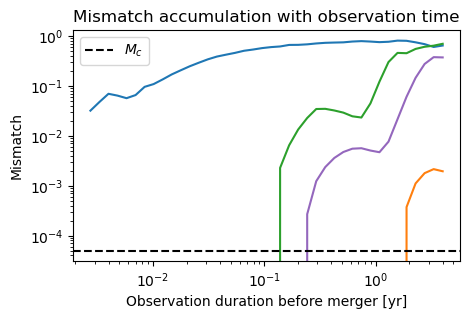

In [54]:
def merger_time(f, m1, m2):
    m1 *= M_sun
    m2 *= M_sun

    chirp_mass = ((m1*m2)**(3/5)) / ((m1+m2)**(1/5))
    a_V = (np.pi * G * chirp_mass / c**3)**(-5/3)
    return (5 * a_V) / (16 * np.pi * f**(8/3))

obs_times = np.logspace(
    np.log10(1/365),   # 1 day
    np.log10(4),       # 4 years
    40)

plt.figure(figsize=(5,3))

for j in range(5):
    sys_i = idx_test[j]

    f_axis = (x_grid * (f_tau_arr[sys_i] - fc[sys_i]) + fc[sys_i])

    dphi_true = np.exp(Y_te_true[j])
    dphi_pred = np.exp(Y_te_pred[j])

    f_dense, dphi_true_dense = resample_waveform_data(f_axis, dphi_true)

    _, dphi_pred_dense = resample_waveform_data(f_axis, dphi_pred)

    t_merge = merger_time(f_dense, m1[sys_i], m2[sys_i]) / YR

    M_t = []

    for t_obs in obs_times:
        mask = t_merge <= t_obs
        if np.sum(mask) < 100:
            M_t.append(np.nan)
            continue
        M = mismatch(f_dense[mask], dphi_true_dense[mask], dphi_pred_dense[mask], m1[sys_i], m2[sys_i])
        M_t.append(M)

    plt.plot(obs_times, M_t)

plt.axhline(M_c, color='black', linestyle='--', label=r"$M_c$")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Observation duration before merger [yr]")
plt.ylabel("Mismatch")
plt.legend()
plt.title("Mismatch accumulation with observation time")
plt.show()